# Euler's method on a two-body orbit

ASTR 5820 &middot; in-class demonstration

The two-body problem is exactly solvable, so we know the right answer. That makes
it the best possible test case for a numerical integrator: every departure from a
closed ellipse is error we put there ourselves.

Everything below comes from `astrotools`, so what you see here is the same code you
will use on the problem sets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astrotools import constants as c
from astrotools.nbody import integrators as ig
from astrotools.nbody import twobody as tb

## The test orbit

Start at pericentre of an $a = 1$ AU, $e = 0.3$ orbit around the Sun. After exactly
one period the planet should be back where it started, so the distance between the
final and initial positions is the error of the run.

In [2]:
a, e = c.AU, 0.3

P = tb.orbital_period(a)
y0 = tb.initial_conditions(a, e)

print(f"P  = {P / c.YR:.3f} yr")
print(f"r0 = {y0[0] / c.AU:.3f} AU,  v0 = {y0[3] / 1e3:.2f} km/s")

# The exact ellipse, for comparison.
nu = np.linspace(0, 2 * np.pi, 400)
r_exact = a * (1 - e ** 2) / (1 + e * np.cos(nu))
xy_exact = np.array([r_exact * np.cos(nu), r_exact * np.sin(nu)]) / c.AU

P  = 1.000 yr
r0 = 0.700 AU,  v0 = 40.59 km/s


## One orbit, three timesteps

Each run covers exactly one period. The only thing that changes is how many steps
we chop it into.

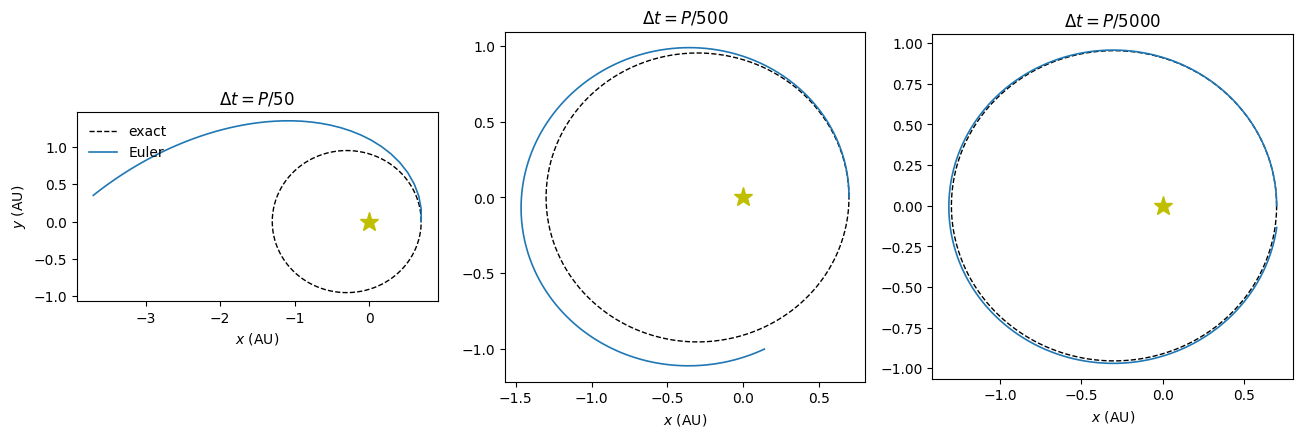

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, n in zip(axes, [50, 500, 5000]):
    t, y = ig.integrate(ig.euler_step, tb.kepler_derivs, y0, (0.0, P), P / n)
    ax.plot(*xy_exact, 'k--', lw=1, label='exact')
    ax.plot(y[:, 0] / c.AU, y[:, 1] / c.AU, '-', lw=1.2, label='Euler')
    ax.plot(0, 0, 'y*', ms=14)
    ax.set_aspect('equal')
    ax.set_title(f'$\\Delta t = P/{n}$')
    ax.set_xlabel('$x$ (AU)')

axes[0].set_ylabel('$y$ (AU)')
axes[0].legend(frameon=False, loc='upper left')
plt.tight_layout()

Euler always steps along the *current* velocity, so at every step it leaves the
ellipse along the tangent and lands slightly too far out. The errors accumulate in
the same direction every orbit, and the orbit spirals outward.

## Where does the energy go?

The specific orbital energy $E = v^2/2 - \mu/r$ is constant for the true motion, so
its drift is a sharper diagnostic than the trajectory. `relative_drift` returns
$(E(t) - E(0)) / |E(0)|$.

after 10 orbits:  drift = +0.538


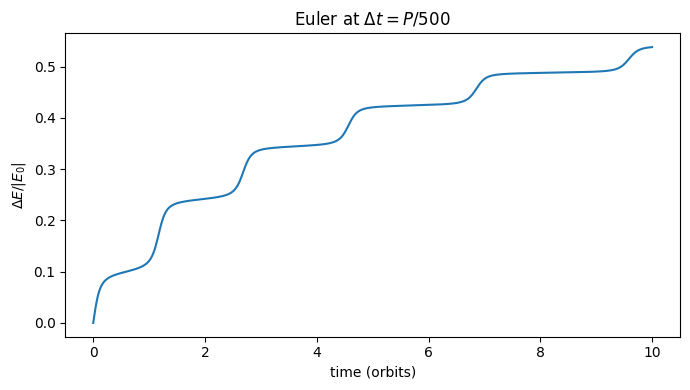

In [4]:
n_per_orbit, n_orbits = 500, 10

t, y = ig.integrate(ig.euler_step, tb.kepler_derivs, y0,
                    (0.0, n_orbits * P), P / n_per_orbit,
                    store_every=10)

drift = tb.relative_drift(tb.specific_energy(y))

plt.figure(figsize=(7, 4))
plt.plot(t / P, drift)
plt.xlabel('time (orbits)')
plt.ylabel(r'$\Delta E / |E_0|$')
plt.title(r'Euler at $\Delta t = P/500$')
plt.tight_layout()

print(f"after {n_orbits} orbits:  drift = {drift[-1]:+.3f}")

The orbit is losing binding energy monotonically. Nothing in the scheme conserves
it, and nothing brings it back.

## Does a smaller timestep fix it?

Back to a single orbit, measuring the error as the distance between the final
position and the starting point.

In [5]:
print(f"{'steps/orbit':>12}  {'|r - r0| / a':>14}")

for n in [200, 400, 800, 1600, 3200, 6400]:
    t, y = ig.integrate(ig.euler_step, tb.kepler_derivs, y0, (0.0, P), P / n,
                        store_every=n)
    err = np.hypot(*(y[-1, :2] - y0[:2])) / a
    print(f"{n:12d}  {err:14.4f}")

 steps/orbit    |r - r0| / a
         200          2.1670
         400          1.3612
         800          0.7731
        1600          0.4078
        3200          0.2078
        6400          0.1046


Once the timestep is small enough, each halving of $\Delta t$ buys a factor of two.
That is what *first order* means, and it is a poor exchange rate: three more digits
of accuracy costs a thousand times the work.

Two questions to take away:

1. What would a scheme that buys a factor of 16 per halving cost per step, and when
   is that trade worth taking?
2. The energy drift above is not random, it accumulates. Does integrating more
   accurately remove it, or only postpone it?